Estimated RANSAC Slope (m): -0.8899
Estimated RANSAC Intercept (c): 113.0958


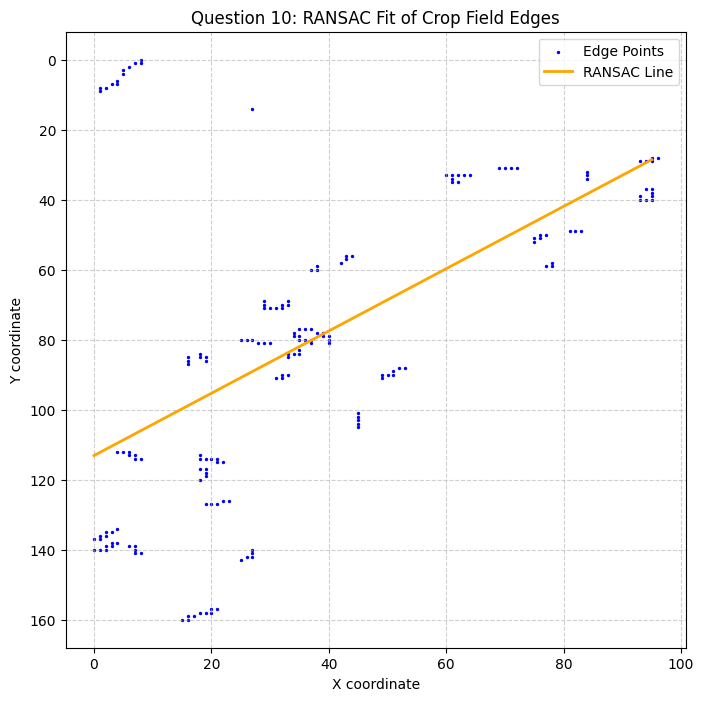

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor


image_filename = 'IMages/1c.jpg'
img = cv.imread(image_filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find {image_filename}. Check your folder path!")
else:
    # Apply Canny and get coordinates
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    
    # RANSAC requires the X data to be a 2D array (a column vector)
    x = indices[1].reshape(-1, 1) 
    y = indices[0]

    # RANSAC Fit Estimation
    # Initialize the RANSAC regressor
    ransac = RANSACRegressor(random_state=42)
    ransac.fit(x, y)

    # Extract the estimated slope (m) and intercept (c)
    m_ransac = ransac.estimator_.coef_[0]
    c_ransac = ransac.estimator_.intercept_

    print(f"Estimated RANSAC Slope (m): {m_ransac:.4f}")
    print(f"Estimated RANSAC Intercept (c): {c_ransac:.4f}")

    # Calculate the y values for the fitted line
    # We create a line covering the full range of our x values to draw it properly
    line_x = np.arange(x.min(), x.max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_x)

    # Create the Scatter Plot with the RANSAC Fitted Line
 
    plt.figure(figsize=(8, 8))
    
    # Plot original edge points
    plt.scatter(x, y, s=2, c='blue', label='Edge Points') 
    
    # Plot the RANSAC line
    plt.plot(line_x, line_y_ransac, color='orange', linewidth=2, label='RANSAC Line')

    # Invert the y-axis for image coordinates
    plt.gca().invert_yaxis() 

    plt.title('Question 10: RANSAC Fit of Crop Field Edges')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) 
    
    plt.show()